In [3]:
!pip install langgraph langchain langchain-openai langchain-chroma langchain-tavily python-dotenv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/

In [4]:
# ============================================================
# IMPORTS
# ============================================================

import os
import operator
import itertools
from datetime import datetime
from typing import Annotated, List, Dict
from typing_extensions import TypedDict

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_core.messages import AIMessage, HumanMessage

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

In [8]:
# ============================================================
# DAY 2 LAB — SOLUTION  (USE_FAKE=1 compatible, with HITL)
# ============================================================
# Graph compiled globally; interrupt_before=["report_generation"]
# HUMAN-IN-THE-LOOP: pause before report, approve / refine / cancel
# ============================================================

import os
import itertools
import operator
from datetime import datetime
from typing import Annotated, List, Dict
from typing_extensions import TypedDict
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

# ============================================================
# CONFIG
# ============================================================
load_dotenv()

os.environ.setdefault("USE_FAKE", "1")
FAKE_MODE = os.getenv("USE_FAKE", "0") == "1"

LLM_BASE_URL = os.getenv("LLM_BASE_URL")
LLM_MODEL    = os.getenv("LLM_MODEL", "gpt-4o-mini")

MAX_RESEARCH_ITERATIONS = 3
QUALITY_THRESHOLD       = 7

# ============================================================
# MODELS, SEARCH, EMBEDDINGS
# ============================================================
if FAKE_MODE:
    from langchain_core.language_models.fake_chat_models import (
        GenericFakeChatModel,
    )
    from langchain_core.embeddings import DeterministicFakeEmbedding

    analysis_llm = GenericFakeChatModel(messages=itertools.cycle([
        AIMessage(content=(
            "1. Summary: The source discusses agentic AI adoption in enterprises.\n"
            "2. Importance Score: 7\n"
            "3. Business Impact: Significant automation potential across workflows."
        )),
    ]))

    report_llm = GenericFakeChatModel(messages=itertools.cycle([
        AIMessage(content=(
            "# Enterprise Research Report (FAKE MODE)\n\n"
            "## Executive Summary\nThis report was generated in offline (fake) mode.\n\n"
            "## Key Findings\n- The graph looped once on low quality, then proceeded.\n"
            "- Agentic AI adoption is accelerating across Fortune 500 companies.\n\n"
            "## Risks\n- Hallucination in autonomous pipelines.\n"
            "- Data governance gaps.\n\n"
            "## Opportunities\n- 30-40 % productivity gains documented in case studies.\n\n"
            "## Strategic Recommendations\n- Pilot with low-risk workflows first.\n"
            "- Set USE_FAKE=0 and add API keys to run for real."
        )),
    ]))

    # Scripted scores: first evaluation returns 4 (triggers retry),
    # second returns 9 (passes). see the conditional edge loop once.
    _fake_scores = iter([4, 9, 9, 9])

    embedding_model = DeterministicFakeEmbedding(size=384)

    def run_search(query: str) -> List[Dict]:
        return [
            {
                "url":     "https://example.com/agentic-ai-report",
                "title":   "State of Agentic AI 2026",
                "content": f"(fixture) Overview of {query}: enterprises are adopting "
                           "graph-orchestrated agents at scale.",
            },
            {
                "url":     "https://example.com/langgraph-case-study",
                "title":   "LangGraph in Production",
                "content": f"(fixture) Case study relevant to {query}: stateful "
                           "workflows with conditional routing cut cycle time by 35 %.",
            },
        ]

else:
    from langchain_openai import ChatOpenAI, OpenAIEmbeddings
    from langchain_tavily import TavilySearch

    if not os.getenv("OPENAI_API_KEY"):
        raise ValueError("Missing OPENAI_API_KEY (or set USE_FAKE=1)")
    if not os.getenv("TAVILY_API_KEY"):
        raise ValueError("Missing TAVILY_API_KEY (or set USE_FAKE=1)")

    _llm         = ChatOpenAI(model=LLM_MODEL, temperature=0,
                              base_url=LLM_BASE_URL)
    analysis_llm = _llm
    report_llm   = _llm
    embedding_model = OpenAIEmbeddings()

    _search_tool = TavilySearch(max_results=5)

    def run_search(query: str) -> List[Dict]:
        response = _search_tool.invoke({"query": query})
        return response.get("results", []) if isinstance(response, dict) else response

# ============================================================
# VECTOR STORE (Chroma persistent → InMemoryVectorStore fallback)
# ============================================================
try:
    from langchain_chroma import Chroma
    vector_store = Chroma(
        collection_name="enterprise_research_memory",
        embedding_function=embedding_model,
        persist_directory="./enterprise_memory_db",
    )
    print("[setup] Using Chroma (persistent vector memory).")
except ImportError:
    from langchain_core.vectorstores import InMemoryVectorStore
    vector_store = InMemoryVectorStore(embedding=embedding_model)
    print("[setup] chromadb not installed — using in-memory vector store.")

# ============================================================
# STRUCTURED OUTPUT — quality score via Pydantic
# ============================================================
class QualityScore(BaseModel):
    """Evaluation of research quality."""
    score:     int = Field(ge=1, le=10, description="Overall quality 1-10")
    reasoning: str = Field(description="One-sentence justification")


def evaluate_quality(analyzed_data) -> QualityScore:
    if FAKE_MODE:
        return QualityScore(
            score=next(_fake_scores),
            reasoning="Scripted score (fake mode).",
        )
    evaluator = analysis_llm.with_structured_output(QualityScore)
    return evaluator.invoke([HumanMessage(content=(
        "Evaluate the overall quality of this research on a 1-10 scale.\n\n"
        f"Research:\n{analyzed_data}"
    ))])

# ============================================================
# STATE
# execution_logs uses operator.add (reducer) so every node
# APPENDS its lines — no node overwrites another's logs.
# ============================================================
class AgentState(TypedDict):
    topic:           str
    search_query:    str
    collected_data:  List[Dict]
    analyzed_data:   List[Dict]
    quality_score:   int
    iteration_count: int
    final_report:    str
    execution_logs:  Annotated[List[str], operator.add]


def log(message: str) -> List[str]:
    """Print a timestamped line AND return it as a list for execution_logs."""
    line = f"[{datetime.now():%Y-%m-%d %H:%M:%S}] {message}"
    print(line)
    return [line]

# ============================================================
# NODES
# ============================================================

def research_collection_node(state: AgentState) -> dict:
    """Search the web. Each retry uses a different query (loop guard pt 1)."""
    iteration = state["iteration_count"] + 1
    refinements = [
        state["topic"],
        f"{state['topic']} latest developments case studies",
        f"{state['topic']} industry analysis best practices",
    ]
    query   = refinements[min(iteration - 1, len(refinements) - 1)]
    results = run_search(query)
    return {
        "search_query":    query,
        "collected_data":  results,
        "iteration_count": iteration,
        "execution_logs":  log(
            f"Iteration {iteration}: collected {len(results)} sources "
            f"for query: '{query}'"
        ),
    }


def memory_storage_node(state: AgentState) -> dict:
    """Persist source contents in the vector store for RAG."""
    documents = [
        item.get("content", "")
        for item in state["collected_data"]
        if item.get("content")
    ]
    if documents:
        vector_store.add_texts(documents)
    return {"execution_logs": log(f"Stored {len(documents)} documents in vector memory.")}


def analysis_node(state: AgentState) -> dict:
    """LLM-analyze each source with RAG context from past iterations."""
    analyzed = []
    for item in state["collected_data"]:
        content = item.get("content", "")
        related = vector_store.similarity_search(content, k=2)
        related_context = "\n".join(d.page_content for d in related)

        response = analysis_llm.invoke([HumanMessage(content=(
            "Analyze the following research content.\n\n"
            f"Content:\n{content}\n\n"
            f"Related prior research from memory:\n{related_context}\n\n"
            "Generate:\n1. Summary\n2. Importance Score (1-10)\n3. Business Impact"
        ))])
        analyzed.append({
            "source":   item.get("url", "Unknown"),
            "title":    item.get("title", "Unknown"),
            "analysis": response.content,
        })
    return {
        "analyzed_data": analyzed,
        "execution_logs": log(f"Analyzed {len(analyzed)} sources."),
    }


def quality_evaluation_node(state: AgentState) -> dict:
    """Score research quality with structured output — never int()."""
    result = evaluate_quality(state["analyzed_data"])
    return {
        "quality_score": result.score,
        "execution_logs": log(
            f"Quality score = {result.score} ({result.reasoning})"
        ),
    }


def report_generation_node(state: AgentState) -> dict:
    """Generate the final enterprise report."""
    response = report_llm.invoke([HumanMessage(content=(
        "Generate a professional enterprise research report.\n\n"
        f"Topic:\n{state['topic']}\n\n"
        f"Research Analysis:\n{state['analyzed_data']}\n\n"
        "Structure: Executive Summary | Key Findings | Risks | "
        "Opportunities | Strategic Recommendations"
    ))])
    return {
        "final_report":  response.content,
        "execution_logs": log("Final report generated."),
    }


def audit_node(state: AgentState) -> dict:
    return {"execution_logs": log(
        f"Audit complete. Iterations: {state['iteration_count']}, "
        f"final quality: {state['quality_score']}."
    )}

# ============================================================
# CONDITIONAL EDGE — loop guard pt 2: hard iteration cap
# ============================================================
def dynamic_router(state: AgentState) -> str:
    score     = state["quality_score"]
    iteration = state["iteration_count"]
    if score >= QUALITY_THRESHOLD:
        print(f"  → Quality {score} >= {QUALITY_THRESHOLD}: proceeding to report.")
        return "report_generation"
    if iteration >= MAX_RESEARCH_ITERATIONS:
        print(f"  → Max iterations ({iteration}) reached: proceeding anyway.")
        return "report_generation"
    print(f"  → Quality {score} < {QUALITY_THRESHOLD}: recollecting (iter {iteration}).")
    return "research_collection"

# ============================================================
# WIRE THE GRAPH
# ============================================================
workflow = StateGraph(AgentState)

workflow.add_node("research_collection", research_collection_node)
workflow.add_node("memory_storage",      memory_storage_node)
workflow.add_node("analysis",            analysis_node)
workflow.add_node("quality_evaluation",  quality_evaluation_node)
workflow.add_node("report_generation",   report_generation_node)
workflow.add_node("audit",               audit_node)

workflow.add_edge(START,                  "research_collection")
workflow.add_edge("research_collection",  "memory_storage")
workflow.add_edge("memory_storage",       "analysis")
workflow.add_edge("analysis",             "quality_evaluation")
workflow.add_conditional_edges(
    "quality_evaluation",
    dynamic_router,
    {
        "research_collection": "research_collection",
        "report_generation":   "report_generation",
    },
)
workflow.add_edge("report_generation", "audit")
workflow.add_edge("audit", END)

# ============================================================
# COMPILE — with checkpointer AND interrupt_before report
#
# interrupt_before=["report_generation"] tells LangGraph to
# PAUSE the graph right before that node runs, save state to
# the checkpointer, and return control to us. We can then:
#   • inspect / modify state with app.update_state()
#   • resume by calling app.stream(None, config)
#   • cancel by simply not resuming
# ============================================================
checkpointer = InMemorySaver()

app = workflow.compile(
    checkpointer=checkpointer,
    interrupt_before=["report_generation"],
)

print("\n--- GRAPH STRUCTURE (paste into https://mermaid.live) ---")
print(app.get_graph().draw_mermaid())

# ============================================================
# HUMAN-IN-THE-LOOP RUNNER
# ============================================================
def run_with_human_approval(initial_state: dict, config: dict) -> None:
    """
    Phase 1 — run until the interrupt (before report_generation).
    Phase 2 — show human the research, ask for approval.
    Phase 3 — resume, refine topic, or cancel based on input.
    """

    # Phase 1: collect → memory → analyze → evaluate (loop if needed)
    print("\n" + "=" * 60)
    print("PHASE 1 — RESEARCH (running until human checkpoint)")
    print("=" * 60)

    for _ in app.stream(initial_state, config, stream_mode="values"):
        pass   # progress already printed by log()

    # Check that we actually paused (not that it finished early)
    snapshot = app.get_state(config)
    if "report_generation" not in (snapshot.next or []):
        print("\n[!] Graph finished without reaching the interrupt. "
              "Check routing logic.")
        return

    # Phase 2: show research summary to the human
    state = snapshot.values
    print("\n" + "=" * 60)
    print("⏸  HUMAN CHECKPOINT — research complete, awaiting approval")
    print("=" * 60)
    print(f"  Topic:         {state['topic']}")
    print(f"  Iterations:    {state['iteration_count']}")
    print(f"  Quality score: {state['quality_score']} / 10")
    print(f"  Sources:       {len(state['analyzed_data'])}")
    print()
    for src in state["analyzed_data"]:
        print(f"  [{src['title']}]  {src['source']}")
        # Print just the first line of each analysis so it fits on screen
        first_line = src["analysis"].split("\n")[0]
        print(f"    {first_line}")
    print()

    # Phase 3: get human decision
    print("Options:")
    print("  [y] Approve — generate the report as-is")
    print("  [r] Refine  — change the topic and re-run research")
    print("  [n] Cancel  — discard and exit")
    print()

    while True:
        choice = input("Your choice (y / r / n): ").strip().lower()
        if choice in ("y", "r", "n"):
            break
        print("  Please enter y, r, or n.")

    if choice == "n":
        print("\n[cancelled] Workflow discarded. No report generated.")
        return

    if choice == "r":
        new_topic = input("Enter a refined topic: ").strip()
        if new_topic:
            # update_state() patches the frozen checkpoint in-place;
            # the resumed graph will pick up the new topic.
            app.update_state(config, {
                "topic":           new_topic,
                "iteration_count": 0,
                "quality_score":   0,
                "collected_data":  [],
                "analyzed_data":   [],
            })
            print(f"\n[updated] Topic changed to: '{new_topic}'")

            # Re-run the full research loop with the new topic,
            # then return to the checkpoint again.
            print("\n" + "=" * 60)
            print("PHASE 1b — RE-RUNNING RESEARCH with refined topic")
            print("=" * 60)

            new_config = {
                "configurable": {
                    "thread_id": config["configurable"]["thread_id"] + "-refined"
                }
            }
            refined_state = {**initial_state, "topic": new_topic}
            run_with_human_approval(refined_state, new_config)
            return

    # choice == "y" (or after a refined-topic approval): resume
    print("\n" + "=" * 60)
    print("PHASE 2 — REPORT GENERATION (resuming graph)")
    print("=" * 60)

    # Passing None as the state resumes from the saved checkpoint.
    final_state = None
    for update in app.stream(None, config, stream_mode="values"):
        final_state = update

    if final_state is None:
        final_state = app.get_state(config).values

    print("\n" + "=" * 60)
    print("FINAL ENTERPRISE RESEARCH REPORT")
    print("=" * 60)
    print(final_state["final_report"])

    print("\n" + "=" * 60)
    print("FULL EXECUTION LOG")
    print("=" * 60)
    for line in final_state["execution_logs"]:
        print(line)


# ============================================================
# ENTRY POINT
# ============================================================
if __name__ == "__main__":
    initial_state = {
        "topic":           "Enterprise Agentic AI Systems",
        "search_query":    "",
        "collected_data":  [],
        "analyzed_data":   [],
        "quality_score":   0,
        "iteration_count": 0,
        "final_report":    "",
        "execution_logs":  [],
    }


    config = {"configurable": {"thread_id": "lab-day2-run-1"}}

    run_with_human_approval(initial_state, config)

[setup] chromadb not installed — using in-memory vector store.

--- GRAPH STRUCTURE (paste into https://mermaid.live) ---
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	research_collection(research_collection)
	memory_storage(memory_storage)
	analysis(analysis)
	quality_evaluation(quality_evaluation)
	report_generation(report_generation<hr/><small><em>__interrupt = before</em></small>)
	audit(audit)
	__end__([<p>__end__</p>]):::last
	__start__ --> research_collection;
	analysis --> quality_evaluation;
	memory_storage --> analysis;
	quality_evaluation -.-> report_generation;
	quality_evaluation -.-> research_collection;
	report_generation --> audit;
	research_collection --> memory_storage;
	audit --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc


PHASE 1 — RESEARCH (running until human checkpoint)
[2026-07-21 06:37:11] Iteration 1: collected 2 sources for query: 'Enter

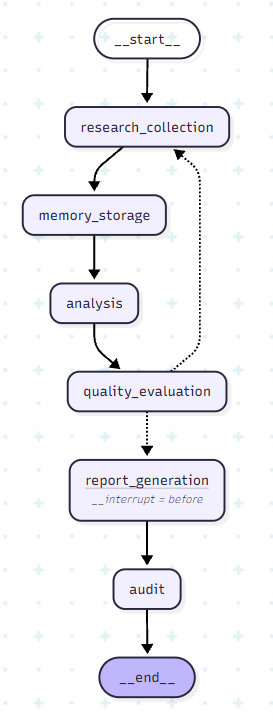